In [3]:
import os
import sys

# Move up one level to the project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# Add the new current directory to the Python path
sys.path.insert(0, os.getcwd())

# 02 — Attacking model v1 (Part 10)

Can a bettor beat the v1 model? We test mean-reversion and momentum strategies, two ways:

- **Static** — per-contract expected value inside chosen pockets, to find *where* the single
  displayed curve is mispriced.
- **Dynamic** — the suspected exploit run through the live engine *inside a background pool*, with
  its PnL isolated, then a capacity sweep to see how much it can actually extract.

The finding from the original study: the house prices off one momentum curve, but the real
probability of up depends on the volatility regime; in **low volatility**, following an **extreme**
move is mispriced in the bettor's favour. Everywhere else the vig holds. Inside a realistic pool the
pocket is small and capacity-limited.

Note: the pocket only appears in data with real volatility-regime structure. On a homogeneous feed
there is no pocket and every strategy simply pays the vig.

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from snapmarket.data import load_oracle_prices
from snapmarket.features import build_features, contract_entries, quantile_bins
from snapmarket.models import ModelParameters, build_momentum_lookup_model
from snapmarket.strategies import noise_pool, pocket_follower
from snapmarket.engine import simulate, build_contract_table, pocket_edge

parameters = ModelParameters()
features = build_features(load_oracle_prices(), parameters)
model = build_momentum_lookup_model(features, parameters)

table = build_contract_table(model, features)
print(f"{len(table.entries):,} contracts | training {table.training_mask.sum():,} | test {table.test_mask.sum():,}")

# features sliced at contract entries (for pocket masks), and thresholds frozen on training
momentum_at_entry   = table.feature_at_entry(features.standardized_momentum)
abs_momentum_entry  = table.feature_at_entry(features.absolute_standardized_momentum)
volatility_at_entry = table.feature_at_entry(features.annualized_volatility)

549,102 contracts | training 219,640 | test 329,462


## Section 1 — Sanity: the vig holds on the whole population

Betting either side over all contracts should lose about the margin. If this does not reproduce, the
measurement is wrong and nothing below can be trusted.

In [5]:
def show(label, result):
    print(f"  {label:38s} count={result['count']:>6}  realized_up={result['realized_up_rate']:.3f}  "
          f"displayed={result['house_probability']:.3f}  bettor_edge={result['bettor_edge']:+.3%}  "
          f"house_edge={result['house_edge']:+.3%}")

everything = np.ones(len(table.entries), bool)
recent_up_move = momentum_at_entry > 0
show("all contracts, bet up",            pocket_edge(table, everything & table.test_mask, "up"))
show("all contracts, bet down",          pocket_edge(table, everything & table.test_mask, "down"))
show("recent up move, follow (bet up)",  pocket_edge(table, recent_up_move & table.test_mask, "up"))
show("recent up move, fade (bet down)",  pocket_edge(table, recent_up_move & table.test_mask, "down"))

  all contracts, bet up                  count=329462  realized_up=0.503  displayed=0.500  bettor_edge=-12.295%  house_edge=+12.295%
  all contracts, bet down                count=329462  realized_up=0.503  displayed=0.500  bettor_edge=-13.415%  house_edge=+13.415%
  recent up move, follow (bet up)        count=161865  realized_up=0.560  displayed=0.532  bettor_edge=-7.969%  house_edge=+7.969%
  recent up move, fade (bet down)        count=161865  realized_up=0.560  displayed=0.532  bettor_edge=-17.774%  house_edge=+17.774%


## Section 2 — Where the curve is wrong: calibration by volatility regime

The house shows one curve. The real probability of up by momentum bin differs across volatility
terciles — the gap is the mispricing.

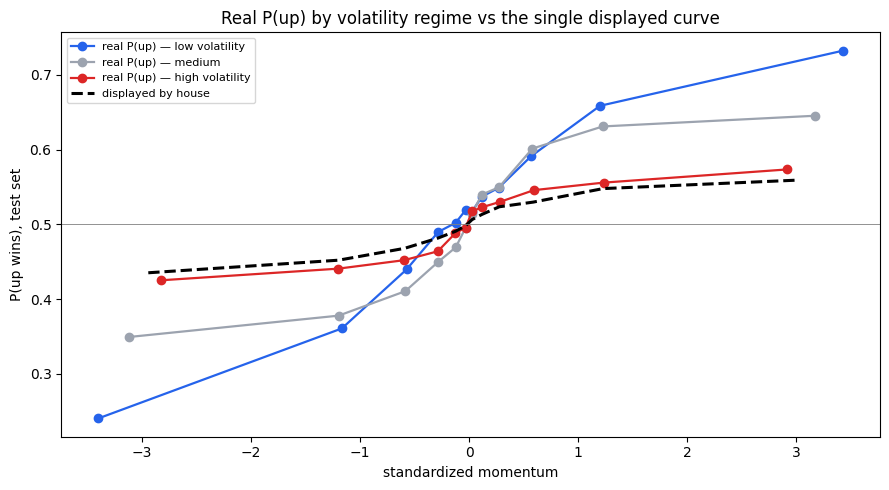

In [6]:
number_of_momentum_bins = 12
momentum_bin = quantile_bins(momentum_at_entry, momentum_at_entry[table.training_mask], number_of_momentum_bins)
volatility_tercile = quantile_bins(volatility_at_entry, volatility_at_entry[table.training_mask], 3)

plt.figure(figsize=(9, 5))
for tercile, label, color in [(0, "low volatility", "#2563eb"), (1, "medium", "#9ca3af"), (2, "high volatility", "#dc2626")]:
    xs, ys = [], []
    for b in range(number_of_momentum_bins):
        subset = table.test_mask & (momentum_bin == b) & (volatility_tercile == tercile)
        if subset.sum() < 200: continue
        xs.append(momentum_at_entry[subset].mean()); ys.append(table.realized_up_rate[subset].mean())
    plt.plot(xs, ys, "o-", color=color, lw=1.6, label=f"real P(up) — {label}")

xs, ys = [], []
for b in range(number_of_momentum_bins):
    subset = table.test_mask & (momentum_bin == b)
    if subset.sum() < 200: continue
    xs.append(momentum_at_entry[subset].mean()); ys.append(table.house_probability[subset].mean())
plt.plot(xs, ys, "k--", lw=2.2, label="displayed by house")
plt.axhline(0.5, color="grey", lw=0.6)
plt.xlabel("standardized momentum"); plt.ylabel("P(up wins), test set")
plt.title("Real P(up) by volatility regime vs the single displayed curve")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Section 3 — The exploit is to follow the move at the extremes, in low volatility

**3a.** Following the move in the low-volatility tail — how the edge grows as the move gets more extreme.

In [7]:
low_volatility_threshold = np.quantile(volatility_at_entry[table.training_mask], 1/3)
low_volatility = volatility_at_entry < low_volatility_threshold

print(f"{'tail fraction':>14}{'EV follow up':>16}{'count up':>10}{'EV follow down':>18}{'count down':>12}")
for upper_quantile in [0.80, 0.85, 0.90, 0.95, 0.975, 0.99]:
    high = np.quantile(momentum_at_entry[table.training_mask], upper_quantile)
    low  = np.quantile(momentum_at_entry[table.training_mask], 1 - upper_quantile)
    upper_pocket = table.test_mask & low_volatility & (momentum_at_entry >= high)
    lower_pocket = table.test_mask & low_volatility & (momentum_at_entry <= low)
    ev_up   = pocket_edge(table, upper_pocket, "up")["bettor_edge"]   if upper_pocket.sum() > 100 else np.nan
    ev_down = pocket_edge(table, lower_pocket, "down")["bettor_edge"] if lower_pocket.sum() > 100 else np.nan
    print(f"{1-upper_quantile:>14.3f}{ev_up:>+16.2%}{upper_pocket.sum():>10}{ev_down:>+18.2%}{lower_pocket.sum():>12}")

 tail fraction    EV follow up  count up    EV follow down  count down
         0.200          +7.94%      7986            +7.56%        7775
         0.150         +11.03%      5548           +11.25%        5565
         0.100         +13.25%      3735           +16.52%        3834
         0.050         +14.44%      2147           +18.99%        2308
         0.025         +15.16%      1299           +21.15%        1396
         0.010         +19.03%       650           +20.90%         738


**3b.** Follow vs fade, by absolute-momentum quartile and volatility tercile (training | test).
Following should pay only in the low-volatility, high-momentum cells.

In [8]:
following_payout = np.where(table.house_probability > 0.5, table.payout_betting_up, table.payout_betting_down)
fading_payout    = np.where(table.house_probability > 0.5, table.payout_betting_down, table.payout_betting_up)
abs_momentum_quartile = quantile_bins(abs_momentum_entry, abs_momentum_entry[table.training_mask], 4)

def cross_table(payout, description):
    print(f"\nBettor expected value — {description} (training | test)")
    print(f"{'':26}{'low vol':>18}{'medium vol':>18}{'high vol':>18}")
    for q in range(4):
        row = f"abs momentum level {q+1}   "
        for tercile in range(3):
            cell = (abs_momentum_quartile == q) & (volatility_tercile == tercile)
            tr = payout[cell & table.training_mask].mean() - 1 if (cell & table.training_mask).sum() > 200 else np.nan
            te = payout[cell & table.test_mask].mean()     - 1 if (cell & table.test_mask).sum()     > 200 else np.nan
            row += f"{tr:>+8.1%} |{te:>+7.1%}  "
        print(row)

cross_table(following_payout, "following the house lean")
cross_table(fading_payout,    "fading the house lean")


Bettor expected value — following the house lean (training | test)
                                     low vol        medium vol          high vol
abs momentum level 1     -11.3% | -10.5%    -10.7% |  -9.8%    -10.1% | -10.9%  
abs momentum level 2      -9.1% | -11.4%     -5.9% |  -7.9%     -8.4% | -10.9%  
abs momentum level 3      -1.1% |  -3.6%     -0.8% |  -1.1%     -9.1% | -10.0%  
abs momentum level 4     +18.0% | +13.6%     +2.9% |  +0.6%     -7.6% | -11.0%  

Bettor expected value — fading the house lean (training | test)
                                     low vol        medium vol          high vol
abs momentum level 1     -13.7% | -14.4%    -14.3% | -15.3%    -15.0% | -14.1%  
abs momentum level 2     -16.1% | -13.6%    -19.6% | -17.4%    -16.9% | -14.2%  
abs momentum level 3     -25.7% | -22.7%    -26.0% | -25.6%    -16.4% | -15.4%  
abs momentum level 4     -51.3% | -45.8%    -32.0% | -29.1%    -18.7% | -14.4%  


## Section 4 — A realistic test: the attacker inside a background pool

Measuring a strategy alone is misleading: the inventory skew reacts to the attacker's own flow. Here
the pocket-follower bets *inside* a noise pool, and its PnL is isolated. Thresholds are frozen on the
training set (no look-ahead).

In [9]:
momentum_high = np.quantile(momentum_at_entry[table.training_mask], 0.90)
momentum_low  = np.quantile(momentum_at_entry[table.training_mask], 0.10)

first_test_index = table.entries[int(0.5 * len(table.entries))]
window_length = 300_000

print("Pocket attacker inside a background pool — separate windows:")
attacker_edges = []
for w in range(10):
    start = first_test_index + w * 400_000
    if start + window_length + 30 >= features.number_of_seconds: break
    attacker = pocket_follower(features, momentum_high, momentum_low, low_volatility_threshold, size=1.0)
    r = simulate(model, features, {"pool": noise_pool(), "attacker": attacker}, start, window_length, seed=100 + w)
    a = r.per_bettor["attacker"]
    attacker_edges.append(a.edge)
    print(f"  window {w}: attacker_edge={a.edge:+.3%}  attacker_pnl={a.pnl:+,.0f}  "
          f"volume_share={a.stake / r.total_volume:.2%}  (house edge {r.house_edge:+.2%})")
attacker_edges = np.array(attacker_edges)
print(f"\n  mean attacker edge = {attacker_edges.mean():+.3%}  (min {attacker_edges.min():+.3%})")

Pocket attacker inside a background pool — separate windows:
  window 0: attacker_edge=+47.197%  attacker_pnl=+110  volume_share=0.00%  (house edge +12.66%)
  window 1: attacker_edge=+10.297%  attacker_pnl=+3,212  volume_share=0.21%  (house edge +12.80%)
  window 2: attacker_edge=+8.043%  attacker_pnl=+1,117  volume_share=0.09%  (house edge +12.59%)
  window 3: attacker_edge=+0.000%  attacker_pnl=+0  volume_share=0.00%  (house edge +12.62%)
  window 4: attacker_edge=+0.000%  attacker_pnl=+0  volume_share=0.00%  (house edge +12.64%)
  window 5: attacker_edge=+11.455%  attacker_pnl=+31,760  volume_share=1.82%  (house edge +12.43%)
  window 6: attacker_edge=+21.258%  attacker_pnl=+674  volume_share=0.02%  (house edge +12.66%)
  window 7: attacker_edge=+7.143%  attacker_pnl=+9,267  volume_share=0.86%  (house edge +12.55%)
  window 8: attacker_edge=+6.116%  attacker_pnl=+28,345  volume_share=3.00%  (house edge +12.18%)
  window 9: attacker_edge=+5.931%  attacker_pnl=+1,157  volume_share=0.1

## Section 5 — Capacity: how much can the attacker extract?

Sweep the attacker's size. As it grows it moves the book against itself (the skew widens), so edge
and house impact are capacity-limited.

In [10]:
windows_to_use = 6

def aggregate(attacker_size):
    attacker_pnl = attacker_stake = house_pnl = volume = 0.0
    for w in range(windows_to_use):
        start = first_test_index + w * 400_000
        if start + window_length + 30 >= features.number_of_seconds: break
        attacker = pocket_follower(features, momentum_high, momentum_low, low_volatility_threshold, size=attacker_size)
        r = simulate(model, features, {"pool": noise_pool(), "attacker": attacker}, start, window_length, seed=100 + w)
        a = r.per_bettor["attacker"]
        attacker_pnl += a.pnl; attacker_stake += a.stake; house_pnl += r.house_pnl; volume += r.total_volume
    return attacker_pnl, attacker_stake, house_pnl, volume

_, _, house_pnl_reference, volume_reference = aggregate(0.0)
house_edge_no_attacker = house_pnl_reference / volume_reference
print(f"House edge with no attacker: {house_edge_no_attacker:+.3%}\n")

print(f"{'size':>6}{'vol share':>12}{'attacker edge':>15}{'attacker pnl':>16}{'house edge':>12}{'vs none':>12}")
for size in [0.1, 1, 3, 5, 8, 10, 13, 16, 20, 25, 30, 50, 100]:
    attacker_pnl, attacker_stake, house_pnl, volume = aggregate(size)
    attacker_edge = attacker_pnl / attacker_stake if attacker_stake else 0.0
    house_edge = house_pnl / volume
    print(f"{size:>6.1f}{attacker_stake / volume:>11.2%}{attacker_edge:>+15.2%}"
          f"{attacker_pnl:>+16,.0f}{house_edge:>+12.3%}{house_edge - house_edge_no_attacker:>+12.3%}")

House edge with no attacker: +12.706%

  size   vol share  attacker edge    attacker pnl  house edge     vs none
   0.1      0.04%        +12.23%          +3,944    +12.697%     -0.009%
   1.0      0.36%        +11.22%         +36,199    +12.621%     -0.084%
   3.0      1.06%         +9.32%         +90,149    +12.472%     -0.233%
   5.0      1.76%         +7.72%        +124,465    +12.350%     -0.356%
   8.0      2.79%         +5.66%        +145,976    +12.207%     -0.499%
  10.0      3.46%         +4.45%        +143,626    +12.133%     -0.572%
  13.0      4.45%         +2.85%        +119,721    +12.047%     -0.659%
  16.0      5.42%         +1.50%         +77,525    +11.981%     -0.725%
  20.0      6.66%         +0.05%          +3,015    +11.914%     -0.792%
  25.0      8.07%         -1.01%         -79,831    +11.831%     -0.875%
  30.0      9.36%         -1.97%        -183,383    +11.778%     -0.927%
  50.0     13.28%         -3.13%        -431,370    +11.517%     -1.188%
 100.0     

## Section 6 — Machine-learning cross-check (optional, needs `xgboost`)

A flexible model on many features should find no pocket the hand-built one missed. It calibrates to
the house almost everywhere; the only place it disagrees profitably is the low-volatility tail.

In [11]:
try:
    import xgboost
except ImportError:
    print("xgboost not installed; skip this cell (pip install xgboost)")
else:
    house_margin, maximum_odds = parameters.house_margin, parameters.maximum_odds
    feature_matrix = pd.DataFrame({
        "standardized_momentum":          momentum_at_entry,
        "absolute_standardized_momentum": abs_momentum_entry,
        "momentum_5_seconds":  table.feature_at_entry(features.momentum_5_seconds) * 1e4,
        "momentum_15_seconds": table.feature_at_entry(features.momentum_15_seconds) * 1e4,
        "momentum_30_seconds": table.feature_at_entry(features.momentum_30_seconds) * 1e4,
        "annualized_volatility":          volatility_at_entry,
        "position_in_range_60":  table.feature_at_entry(features.position_in_range_60_seconds),
        "position_in_range_120": table.feature_at_entry(features.position_in_range_120_seconds),
        "path_efficiency_30":    table.feature_at_entry(features.path_efficiency_30_seconds),
        "acceleration":          table.feature_at_entry(features.acceleration) * 1e4,
        "house_probability":     table.house_probability,
    })
    label = table.up_wins.astype(int)
    finite = np.isfinite(feature_matrix.values).all(axis=1)
    train_rows, test_rows = table.training_mask & finite, table.test_mask & finite

    booster = xgboost.XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=50, reg_lambda=2.0,
        objective="binary:logistic", eval_metric="logloss", n_jobs=-1, random_state=0)
    booster.fit(feature_matrix.values[train_rows], label[train_rows])

    predicted = booster.predict_proba(feature_matrix.values[test_rows])[:, 1]
    displayed = table.house_probability[test_rows]
    realized  = label[test_rows].astype(float)
    up_wins_test = realized == 1
    odds_up   = np.minimum((1 - house_margin) / displayed, maximum_odds)
    odds_down = np.minimum((1 - house_margin) / (1 - displayed), maximum_odds)
    gap = predicted - displayed
    print("Following the model where it disagrees with the house (test set):")
    print(f"{'gap':>8}{'count up':>10}{'EV up':>12}{'count down':>12}{'EV down':>12}")
    for threshold in [0.0, 0.01, 0.02, 0.03, 0.05]:
        bu, bd = gap > threshold, gap < -threshold
        ev_up   = (np.where(up_wins_test,  odds_up,   0.0)[bu].mean() - 1) if bu.sum() > 200 else np.nan
        ev_down = (np.where(~up_wins_test, odds_down, 0.0)[bd].mean() - 1) if bd.sum() > 200 else np.nan
        print(f"{threshold:>8.2f}{bu.sum():>10}{ev_up:>+12.2%}{bd.sum():>12}{ev_down:>+12.2%}")

Following the model where it disagrees with the house (test set):
     gap  count up       EV up  count down     EV down
    0.00    172392      -5.32%      157070      -5.67%
    0.01    148704      -4.41%      134180      -4.50%
    0.02    124963      -3.27%      112378      -3.20%
    0.03    102872      -2.26%       92752      -1.97%
    0.05     68905      -0.19%       60983      +0.53%
